In [12]:
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta


from config import *
from functions2 import *

In [13]:
# FX SHORT gate_state
'''
- Entry: require both edges (20 & 60)
- Exit: fail of 20d edge only (faster exit on rallies)
- Optional consec_on/off and optional 1-day shift
- Optional immediate kill on N consecutive rises
- Optional average-of-N-days drift kill: if rolling mean of returns >= threshold, exit immediately
'''
import numpy as np
import pandas as pd

def standardize_fx_daily_index(s: pd.Series) -> pd.Series:
    """Ensure Mon–Fri daily bars. Your index is date-only; drop Sundays/Saturdays."""
    s = s.sort_index().astype(float).copy()
    s.index = pd.to_datetime(s.index)
    # Monday=0 ... Sunday=6; keep 0..4
    s = s[s.index.dayofweek < 5]
    # if provider emitted duplicates, keep last
    s = s[~s.index.duplicated(keep='last')]
    return s

def carry2060gate(returns, carry_ann, buffer20) -> pd.Series:
    # 20 60 CARRY gate_stateS
    r = returns
    R20 = r.rolling(20, min_periods=20).sum()
    R60 = r.rolling(60, min_periods=60).sum()
    # Calendar-aware carry scaling by actual span (in days) of each window
    idx = pd.Series(r.index, index=r.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    span20_carry = carry_ann * (span20_days / 365.0)
    span60_carry = carry_ann * (span60_days / 365.0)
    signal20on = R20 < -(span20_carry + buffer20)
    signal60on = R60 < -(span60_carry + 3.0 * buffer20)
    both2060_on = (signal20on & signal60on).fillna(False)
    return both2060_on

def wave_rider(
    entry_confirm: pd.Series,
    reconfirm: pd.Series,
    grace_days: int,
    pos_ret: pd.Series | None = None,
    consec_rises_kill: int | None = None,
    returns: pd.Series | None = None,
    avg_rise_window: int | None = None,
    avg_rise_threshold: float | None = None,
 ) -> pd.Series:
    """
    Stateful gate_state continuation with multiple controls:
    - grace_days: maximum days to keep gate_state True without reconfirmation (reconfirm=False).
    - consec_rises_kill: immediately kill gate_state if we see N consecutive rises (r>0).
    - avg-of-N kill: if rolling mean of returns over N days >= threshold, kill immediately.

    entry_confirm: boolean series indicating entry/continuation eligibility (e.g., k-day confirmation met)
    reconfirm: boolean series that resets the grace counter when True (e.g., both2060_on today)
    pos_ret: optional boolean series of (returns > 0) aligned to index
    returns: optional returns series (log returns), aligned to index
    avg_rise_window: window size for rolling mean; disabled if None or <= 0
    avg_rise_threshold: threshold for the rolling mean; kill if mean >= threshold (e.g., 0.0)
    """
    print('wave_rider')
    idx = entry_confirm.index
    out = pd.Series(False, index=idx)
    in_pos = False
    no_reconf = 0
    rises_run = 0
    rmean = None
    if returns is not None and avg_rise_window is not None and avg_rise_window > 0:
        rmean = returns.rolling(avg_rise_window, min_periods=avg_rise_window).mean()
    for i in range(len(idx)):
        # Detect rise today (ignore NaNs as False)
        is_rise = False
        if pos_ret is not None:
            try:
                val = pos_ret.iloc[i]
                is_rise = bool(val) if pd.notna(val) else False
            except Exception:
                is_rise = False
        if not in_pos:
            if bool(entry_confirm.iloc[i]):
                in_pos = True
                no_reconf = 0
                rises_run = 0
        else:
            # Optional avg-of-N-days drift kill
            if rmean is not None and avg_rise_threshold is not None:
                try:
                    mval = rmean.iloc[i]
                except Exception:
                    mval = np.nan
                if pd.notna(mval) and (mval >= avg_rise_threshold):
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    out.iloc[i] = in_pos
                    continue
            # Optional immediate kill on N consecutive rises
            if consec_rises_kill and consec_rises_kill > 0:
                rises_run = (rises_run + 1) if is_rise else 0
                if rises_run >= consec_rises_kill:
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    out.iloc[i] = in_pos
                    continue
            # Grace-days logic based on reconfirmation
            if bool(reconfirm.iloc[i]):
                no_reconf = 0
            else:
                no_reconf += 1
                if no_reconf > grace_days:
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
        out.iloc[i] = in_pos
    return out

def gbpchf_short_gate_simple(
    gbpchf: pd.Series,                 # GBPCHF (CHF per GBP), Mon–Fri
    carry_ann: float,                  # annual carry for LONG GBPCHF (r_GBP - r_CHF)
    consec: int =2,                   # consecutive-day confirmation
    buffer20: float = 0.002,           # fixed buffer for 20d window
    shift_for_signal: bool = True,     # 1-day causal shift
    grace_days: int = 0,               # max days to keep gate_state True without reconfirmation
    consec_rises_kill: int = 1,        # immediate kill if N consecutive rises occur (0 disables)
    avg_rise_window: int = 0,          # rolling mean window for drift kill (0 disables)
    avg_rise_threshold: float = 0.0,   # threshold for rolling mean; kill if mean >= threshold
) -> pd.Series:
    print('GBPCHF_SHORT_GATE_SIMPLE')

    s = standardize_fx_daily_index(gbpchf)
    r = np.log(s).diff()
    # both2060_on = carry2060gate(r, carry_ann, buffer20)



    # print(f'entry_confirm\n{entry_confirm.tail(20)}')

    # ENFORCE GRACE AND KILL RULES
    pos_ret = (r > 0).fillna(False)
    gate_state = wave_rider(
        entry_confirm,
        both2060_on,
        grace_days=grace_days,
        pos_ret=pos_ret,
        consec_rises_kill=consec_rises_kill,
        returns=r,
        avg_rise_window=avg_rise_window,
        avg_rise_threshold=avg_rise_threshold,
    )
    
    both2060_on = pd.Series(True, index=s.index)

    # K-DAY CONFIRMATION
    entry_confirm = (
        both2060_on.astype('int8')
        .rolling(consec, min_periods=consec)
        .sum()
        .ge(consec)
        .astype(bool)
    )

    # CAUSAL 1-DAY SHIFT
    gate_state = gate_state.shift(1, fill_value=False) if shift_for_signal else gate_state
    return gate_state.rename("GBPCHF_short_gate_simple")

def gbpchf_short_gate_simple_asym(
    gbpchf: pd.Series,
    carry_ann: float,
    consec_on: int = 1,
    consec_off: int = 1,
    buffer20: float = 0.002,
    shift_for_signal: bool = False,
    grace_days: int = 0,               # optional extra cap without reconfirmation; 0 disables
    consec_rises_kill: int = 0,        # immediate kill if N consecutive rises occur (0 disables)
    avg_rise_window: int = 0,          # rolling mean window for drift kill (0 disables)
    avg_rise_threshold: float = 0.0,   # threshold for rolling mean; kill if mean >= threshold
) -> pd.Series:
    """Asymmetric variant: entry needs 20&60 edges; exit on 20d edge fail."""
    s = standardize_fx_daily_index(gbpchf)
    r = np.log(s).diff()
    R20 = r.rolling(20, min_periods=20).sum()
    R60 = r.rolling(60, min_periods=60).sum()
    idx = pd.Series(s.index, index=s.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    span20_carry = carry_ann * (span20_days / 365.0)
    span60_carry = carry_ann * (span60_days / 365.0)
    # Edges and entry/exit conditions
    signal20on = R20 < -(span20_carry + (3.0 * buffer20 if consec_off > 1 else buffer20))
    signal60on = R60 < -(span60_carry + 3.0 * buffer20)
    entry_ok = (signal20on & signal60on).fillna(False)
    exit_break = (~signal20on).fillna(False)
    entry_ready = (
        entry_ok.astype('int8').rolling(consec_on, min_periods=consec_on).sum().ge(consec_on)
    )
    exit_ready = (
        exit_break.astype('int8').rolling(consec_off, min_periods=consec_off).sum().ge(consec_off)
    )
    # Rolling mean for avg-of-N drift kill (optional)
    rmean = r.rolling(avg_rise_window, min_periods=avg_rise_window).mean() if avg_rise_window and avg_rise_window > 0 else None
    gate_state = pd.Series(False, index=s.index)
    in_pos = False
    no_reconf = 0
    rises_run = 0
    for i in range(len(s.index)):
        # Evaluate current rise and avg drift
        cur_rise = False
        try:
            rv = r.iloc[i]
            cur_rise = bool(rv > 0) if pd.notna(rv) else False
        except Exception:
            cur_rise = False
        if not in_pos and bool(entry_ready.iloc[i]):
            in_pos = True
            no_reconf = 0
            rises_run = 0
        elif in_pos:
            # Avg-of-N-days drift kill
            if rmean is not None:
                try:
                    mval = rmean.iloc[i]
                except Exception:
                    mval = np.nan
                if pd.notna(mval) and (mval >= avg_rise_threshold):
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    gate_state.iloc[i] = in_pos
                    continue
            # Immediate kill on N consecutive rises
            if consec_rises_kill and consec_rises_kill > 0:
                rises_run = (rises_run + 1) if cur_rise else 0
                if rises_run >= consec_rises_kill:
                    in_pos = False
                    no_reconf = 0
                    rises_run = 0
                    gate_state.iloc[i] = in_pos
                    continue
            # Normal exit if 20d edge fails (with optional consecutive-off requirement)
            if bool(exit_ready.iloc[i]):
                in_pos = False
                no_reconf = 0
                rises_run = 0
            elif grace_days > 0:
                # Optional grace: cap days without entry_ok reconfirmation
                if not bool(entry_ok.iloc[i]):
                    no_reconf += 1
                    if no_reconf > grace_days:
                        in_pos = False
                        no_reconf = 0
                        rises_run = 0
                else:
                    no_reconf = 0
        gate_state.iloc[i] = in_pos
    gate_state = gate_state.shift(1, fill_value=False) if shift_for_signal else gate_state
    return gate_state.rename("GBPCHF_short_gate_simple_asym")

In [14]:
ticker = 'GBPCHF.FOREX'
START = '2020-01-01'
MAX_AGE = 24
# print(f'START {START}')
# print(f'MAX AGE {MAX_AGE} hours')
params = {
    'from': START,  # EODHD uses from/to
    'to': today,
    'api_token': EOD_API
}
url = (f'https://eodhd.com/api/eod/{ticker}')


In [15]:
df = fetch_csv_robust(url, params=params, ticker=ticker, max_age=MAX_AGE)
s = sort_cols(df)
s= standardize_fx_daily_index(s)

gate_stateon = gbpchf_short_gate_simple_asym(
    s,
    carry_ann=0.04,
    consec_on=1,
    consec_off=1,
    buffer20=0.002,
    shift_for_signal=True,
    grace_days=0, # 3
    consec_rises_kill=1,          # disable consecutive-rises kill
    avg_rise_window=1,            # use 3-day average-of-N drift kill
    avg_rise_threshold=0.0,       # kill if 3-day mean return >= 0 (up-drift)
 )
# Print the full last 80 rows without truncation
print("returned (last 80 rows):\n" + gate_stateon.tail(80).to_string())

returned (last 80 rows):
Date
2025-06-09    False
2025-06-10    False
2025-06-11     True
2025-06-12    False
2025-06-13     True
2025-06-16     True
2025-06-17    False
2025-06-18     True
2025-06-19    False
2025-06-20     True
2025-06-23     True
2025-06-24     True
2025-06-25     True
2025-06-26    False
2025-06-27     True
2025-06-30     True
2025-07-01     True
2025-07-02     True
2025-07-03     True
2025-07-04    False
2025-07-07    False
2025-07-08    False
2025-07-09    False
2025-07-10    False
2025-07-11    False
2025-07-14    False
2025-07-15    False
2025-07-16     True
2025-07-17    False
2025-07-18     True
2025-07-21     True
2025-07-22    False
2025-07-23     True
2025-07-24    False
2025-07-25     True
2025-07-28     True
2025-07-29    False
2025-07-30     True
2025-07-31    False
2025-08-01     True
2025-08-04     True
2025-08-05    False
2025-08-06     True
2025-08-07    False
2025-08-08    False
2025-08-11    False
2025-08-12    False
2025-08-13    False
2025-08-14

gateon aligned to price (last 20 rows):
Date
2020-01-01    False
2020-01-02    False
2020-01-03    False
2020-01-06    False
2020-01-07    False
              ...  
2025-09-22     True
2025-09-23     True
2025-09-24     True
2025-09-25     True
2025-09-26     True
Name: GBPCHF_short_gate_simple_asym, Length: 1498, dtype: bool


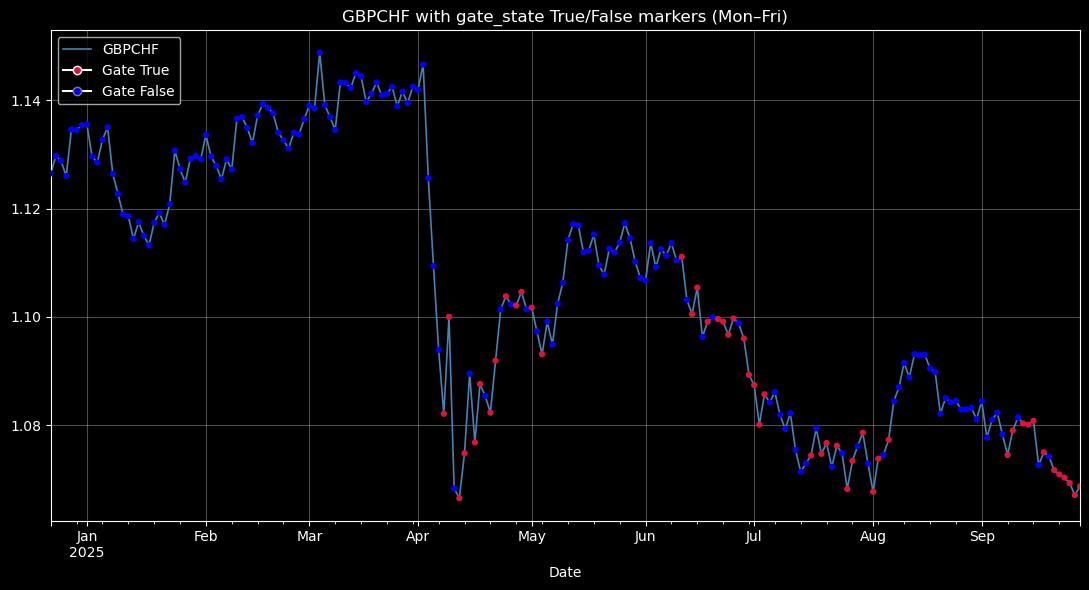

In [16]:
# Overlay gate_state decisions as per-day True/False markers on the price series
# Assumes you already have `s` (price series) and `gateon` (boolean series) defined
# Set how much tail to display (most recent N bars). Set to None for full history.
plt.style.use('dark_background')

TAIL_BARS = 200
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
s=s.tail(200)
s_std_plot = standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label='GBPCHF')
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title('GBPCHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()